# 04 — Model Training

Exploration-level classifier selection (CV grid search over kernel/C/gamma/k/class-weight, calibrated via `CalibratedClassifierCV`), the simplified/restricted configuration actually used in the paper (fixed C/gamma, k chosen per exploration by Youden's J), and the Mixture-of-Experts forward feature selection with a per-fold decision-threshold sweep.

This notebook mirrors `rev2_0_train.ipynb` (the notebook that reproducibly generates the manuscript's numbers) as closely as possible -- the modeling logic here is ported, not reimplemented. The heavy grid search (`run_top_models`, ~30h) and the MoE feature selection (`run_moe_feature_selection`, ~2h) both default to loading the already-computed pkls; nothing here gets recomputed from scratch.

Independently runnable: loads `sacfix_metrics`/`gmm_metrics`/`group_labels` from `../pkls/`.

Part of the pipeline: 01 exploratory data analysis → 02 feature creation → 03 feature analysis → **04 (this notebook)** → 05 model testing.


In [1]:
# Utilities
import pickle

# Data management
import numpy as np
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Machine learning
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GroupShuffleSplit, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, roc_auc_score,
    confusion_matrix, f1_score,
)

# Custom utilities
from futils import get_auc_weights, fit_logistic_regression, pivot_and_flatten


In [2]:
global_random_state = 42

# Only change to True the ones you want to actually run -- everything else
# reuses the pkls already produced by a prior full run.
run_top_models = False             # takes about 30 hours
run_moe_feature_selection = False  # takes about 2 hours


In [3]:
with open('../pkls/metrics/fixation_saccade_metrics.pkl', 'rb') as f:
    sacfix_metrics = pickle.load(f)
with open('../pkls/metrics/gmm_metrics.pkl', 'rb') as f:
    gmm_metrics = pickle.load(f)
with open('../pkls/basic/group_labels.pkl', 'rb') as f:
    group_labels = pickle.load(f)

young_control_patients = group_labels[group_labels['group'] == 'young control']['patient_id'].tolist()
control_patients = group_labels[group_labels['group'] == 'control']['patient_id'].tolist()
pd_patients = group_labels[group_labels['group'] == 'PD']['patient_id'].tolist()

# Same seeded held-out split as 01_exploratory_data_analysis.ipynb
import random
random.seed(42)
control_test = random.sample(control_patients, int(len(control_patients) * 0.2))
pd_test = random.sample(pd_patients, int(len(pd_patients) * 0.2))
test_patients = control_test + pd_test


## Exploration-Level Classifiers

In [4]:
if not run_top_models:
    cv_full_svm = pd.read_pickle('../pkls/model_performances/cv_svm_full.pkl')
else:
    # --- Setup ---
    C_values = list(np.logspace(-3, 3, 7))
    gamma_values = list(np.logspace(-3, 3, 7))
    kernel_options = ['linear', 'rbf']
    datasets = ['fixsac', 'state', 'fixsac+state']

    # class-weight ratios: weight(PD)=r, weight(Control)=1
    class_weight_ratios = [1, 2, 3, 5, 10]

    # --- Patient filter ---
    modeling_patients = [
        p for p in sacfix_metrics['patient_id'].unique()
        if p not in test_patients and p not in young_control_patients
    ]

    # --- CV split ---
    available_patients = sacfix_metrics[
        sacfix_metrics['patient_id'].isin(modeling_patients)
    ]['patient_id'].unique()
    splitter = GroupShuffleSplit(n_splits=20, test_size=0.2, random_state=global_random_state)
    splits_by_fold = {
        fold: {'train': available_patients[train_idx], 'test': available_patients[test_idx]}
        for fold, (train_idx, test_idx) in enumerate(splitter.split(available_patients, groups=available_patients))
    }

    results = []

    for dataset in datasets:
        if dataset == "fixsac":
            df = sacfix_metrics[sacfix_metrics['patient_id'].isin(modeling_patients)].copy()
            df['target'] = (df['group_general'] == 'PD').astype(int)
            df['k_clusters'] = 0
            df = df.drop(columns=['group', 'group_general'])

        elif dataset == "state":
            df = gmm_metrics[gmm_metrics['patient_id'].isin(modeling_patients)].copy()
            df['target'] = (df['group_general'] == 'PD').astype(int)
            df = df.drop(columns=['group', 'group_general'])

        elif dataset == "fixsac+state":
            gmm = gmm_metrics[gmm_metrics['patient_id'].isin(modeling_patients)].copy()
            gmm['target'] = (gmm['group_general'] == 'PD').astype(int)
            sacfix = sacfix_metrics[sacfix_metrics['patient_id'].isin(modeling_patients)].copy()
            sacfix['target'] = (sacfix['group_general'] == 'PD').astype(int)
            df = pd.merge(
                gmm.drop(columns=['group', 'group_general']),
                sacfix.drop(columns=['group', 'group_general']),
                on=['patient_id', 'exploration_id', 'eye', 'target']
            )

        for exploration in df['exploration_id'].unique():
            df_exp = df[df['exploration_id'] == exploration].copy()
            df_exp.drop(columns=['exploration_id'], inplace=True)
            cluster_list = [0] if dataset == "fixsac" else df_exp['k_clusters'].unique()

            for k in cluster_list:
                print(f"Dataset: {dataset} | Exploration: {exploration} | k = {k}")
                df_k = df_exp if dataset == "fixsac" else df_exp[df_exp['k_clusters'] == k].copy()

                if dataset in ['state', 'fixsac+state']:
                    pivot_index = ['patient_id', 'eye', 'target']
                    if dataset == "fixsac+state":
                        pivot_index += ['k_clusters', 'total_saccades', 'total_saccadic_excursion',
                                         'total_fixations', 'average_fixation_time', 'total_scanned_area', 'longest_diagonal']
                    df_k = df_k.pivot_table(index=pivot_index, columns='state',
                                             values=['FO', 'MLT', 'MIL', 'entropy'], aggfunc='first')
                    df_k.columns = [f"{m}_state_{s}" for m, s in df_k.columns]
                    df_k.reset_index(inplace=True)
                    df_k.fillna(0, inplace=True)
                    for feat in ['FO', 'MLT', 'MIL']:
                        df_k[f'max_{feat}'] = df_k[[c for c in df_k.columns if c.startswith(feat)]].max(axis=1)
                        df_k[f'min_{feat}'] = df_k[[c for c in df_k.columns if c.startswith(feat)]].min(axis=1)

                for fold, split in splits_by_fold.items():
                    train_ids, test_ids = split['train'], split['test']
                    X_train = df_k[df_k['patient_id'].isin(train_ids)].drop(columns=['patient_id', 'eye', 'target'])
                    y_train = df_k[df_k['patient_id'].isin(train_ids)]['target']
                    X_test = df_k[df_k['patient_id'].isin(test_ids)].drop(columns=['patient_id', 'eye', 'target'])
                    y_test = df_k[df_k['patient_id'].isin(test_ids)]['target']

                    scaler = StandardScaler()
                    X_train_scaled = scaler.fit_transform(X_train)
                    X_test_scaled = scaler.transform(X_test)

                    for kernel in kernel_options:
                        for C in C_values:
                            for r in class_weight_ratios:
                                class_weight = {0: 1.0, 1: float(r)}
                                gamma_loop = gamma_values if kernel == "rbf" else [None]

                                for gamma in gamma_loop:
                                    svc_kwargs = {"kernel": kernel, "C": C, "class_weight": class_weight, "probability": False}
                                    if kernel == "rbf":
                                        svc_kwargs["gamma"] = gamma
                                    base_model = SVC(**svc_kwargs)
                                    cal_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=global_random_state)
                                    model = CalibratedClassifierCV(estimator=base_model, method="sigmoid", cv=cal_cv)

                                    model.fit(X_train_scaled, y_train)

                                    y_train_pred = model.predict(X_train_scaled)
                                    y_test_pred = model.predict(X_test_scaled)
                                    y_train_prob = model.predict_proba(X_train_scaled)[:, 1]
                                    y_test_prob = model.predict_proba(X_test_scaled)[:, 1]

                                    tn_tr, fp_tr, fn_tr, tp_tr = confusion_matrix(y_train, y_train_pred, labels=[0, 1]).ravel()
                                    tn_te, fp_te, fn_te, tp_te = confusion_matrix(y_test, y_test_pred, labels=[0, 1]).ravel()

                                    train_sens = recall_score(y_train, y_train_pred, zero_division=0)
                                    train_spec = tn_tr / (tn_tr + fp_tr) if (tn_tr + fp_tr) > 0 else 0.0
                                    test_sens = recall_score(y_test, y_test_pred, zero_division=0)
                                    test_spec = tn_te / (tn_te + fp_te) if (tn_te + fp_te) > 0 else 0.0

                                    results.append({
                                        'exploration': exploration, 'dataset': dataset, 'fold': fold,
                                        'random_seed': fold, 'kernel': kernel, 'C': C,
                                        'gamma': gamma, 'k': k, 'class_weight_ratio': r,
                                        'train_accuracy': accuracy_score(y_train, y_train_pred),
                                        'train_precision': precision_score(y_train, y_train_pred, zero_division=0),
                                        'train_sensitivity': train_sens, 'train_specificity': train_spec,
                                        'train_youdens_j': train_sens + train_spec - 1,
                                        'train_f1': f1_score(y_train, y_train_pred, zero_division=0),
                                        'train_roc_auc': roc_auc_score(y_train, y_train_prob),
                                        'test_accuracy': accuracy_score(y_test, y_test_pred),
                                        'test_precision': precision_score(y_test, y_test_pred, zero_division=0),
                                        'test_sensitivity': test_sens, 'test_specificity': test_spec,
                                        'test_youdens_j': test_sens + test_spec - 1,
                                        'test_f1': f1_score(y_test, y_test_pred, zero_division=0),
                                        'test_roc_auc': roc_auc_score(y_test, y_test_prob)
                                    })

    cv_full_svm = pd.DataFrame(results)
    cv_full_svm.to_pickle('../pkls/model_performances/cv_svm_full.pkl')


In [5]:
# gamma = NA for linear kernels; replace before grouping so it groups cleanly
cv_full_svm_for_grouping = cv_full_svm.copy()
cv_full_svm_for_grouping['gamma'] = cv_full_svm_for_grouping.apply(
    lambda row: 'N/A' if row['kernel'] == 'linear' else row['gamma'], axis=1
)

cv_grouped_svm = (
    cv_full_svm_for_grouping
    .groupby(['exploration', 'dataset', 'kernel', 'C', 'gamma', 'k', 'class_weight_ratio'])
    .agg(
        mean_test_accuracy=('test_accuracy', 'mean'), sd_test_accuracy=('test_accuracy', 'std'),
        mean_test_precision=('test_precision', 'mean'), sd_test_precision=('test_precision', 'std'),
        mean_test_sensitivity=('test_sensitivity', 'mean'), sd_test_sensitivity=('test_sensitivity', 'std'),
        mean_test_specificity=('test_specificity', 'mean'), sd_test_specificity=('test_specificity', 'std'),
        mean_test_f1=('test_f1', 'mean'), sd_test_f1=('test_f1', 'std'),
        mean_test_roc_auc=('test_roc_auc', 'mean'), sd_test_roc_auc=('test_roc_auc', 'std'),
        mean_test_youdens_j=('test_youdens_j', 'mean'), sd_test_youdens_j=('test_youdens_j', 'std')
    )
    .reset_index()
)


### Overall best-performing models — letting all parameters optimise

For reference: what the grid search finds if C/gamma are allowed to vary freely per exploration (not what is finally used -- see "Restricted model" below).

In [6]:
# CHOOSING BY AUC
sorted_grouped = cv_grouped_svm.sort_values(by=['exploration', 'mean_test_roc_auc', 'sd_test_roc_auc'], ascending=[True, False, True])
cv_top_models_by_auc = sorted_grouped[sorted_grouped['dataset'] == 'fixsac+state']
cv_top_models_by_auc = cv_top_models_by_auc[cv_top_models_by_auc['kernel'] == 'rbf']
cv_top_models_by_auc = cv_top_models_by_auc[cv_top_models_by_auc['class_weight_ratio'] == 1]
cv_top_models_by_auc = cv_top_models_by_auc.groupby('exploration', as_index=False).first()
numeric_cols = cv_top_models_by_auc.select_dtypes(include='number').columns
cv_top_models_by_auc[numeric_cols] = cv_top_models_by_auc[numeric_cols].round(2)
cv_top_models_by_auc[['exploration', 'dataset', 'kernel', 'k', 'C', 'gamma', 'class_weight_ratio',
                       'mean_test_roc_auc', 'mean_test_f1', 'mean_test_accuracy', 'mean_test_sensitivity', 'mean_test_specificity']]


,exploration,dataset,kernel,k,C,gamma,class_weight_ratio,mean_test_roc_auc,mean_test_f1,mean_test_accuracy,mean_test_sensitivity,mean_test_specificity
0,Exploration_1,fixsac+state,rbf,6,10.0,0.001,1,0.74,0.62,0.67,0.64,0.72
1,Exploration_2,fixsac+state,rbf,23,1.0,0.01,1,0.81,0.65,0.68,0.78,0.62
2,Exploration_3,fixsac+state,rbf,23,0.0,0.001,1,0.64,0.48,0.58,0.50,0.66
3,Exploration_4,fixsac+state,rbf,8,10.0,0.001,1,0.72,0.55,0.64,0.57,0.73
4,Exploration_5,fixsac+state,rbf,42,0.0,0.001,1,0.68,0.56,0.63,0.59,0.70
5,Exploration_6,fixsac+state,rbf,10,10.0,0.01,1,0.73,0.61,0.66,0.66,0.69


In [7]:
# CHOOSING BY YOUDEN J
sorted_grouped = cv_grouped_svm.sort_values(by=['exploration', 'mean_test_youdens_j', 'sd_test_youdens_j'], ascending=[True, False, True])
cv_top_models_by_youden = sorted_grouped[sorted_grouped['dataset'] == 'fixsac+state']
cv_top_models_by_youden = cv_top_models_by_youden[cv_top_models_by_youden['kernel'] == 'rbf']
cv_top_models_by_youden = cv_top_models_by_youden[cv_top_models_by_youden['class_weight_ratio'] == 1]
cv_top_models_by_youden = cv_top_models_by_youden.groupby('exploration', as_index=False).first()
numeric_cols = cv_top_models_by_youden.select_dtypes(include='number').columns
cv_top_models_by_youden[numeric_cols] = cv_top_models_by_youden[numeric_cols].round(2)
cv_top_models_by_youden[['exploration', 'dataset', 'kernel', 'k', 'C', 'gamma', 'class_weight_ratio',
                          'mean_test_youdens_j', 'mean_test_roc_auc', 'mean_test_f1', 'mean_test_accuracy',
                          'mean_test_sensitivity', 'mean_test_specificity']]


,exploration,dataset,kernel,k,C,gamma,class_weight_ratio,mean_test_youdens_j,mean_test_roc_auc,mean_test_f1,mean_test_accuracy,mean_test_sensitivity,mean_test_specificity
0,Exploration_1,fixsac+state,rbf,12,10.0,0.001,1,0.37,0.72,0.63,0.66,0.68,0.70
1,Exploration_2,fixsac+state,rbf,24,0.1,0.01,1,0.46,0.77,0.67,0.71,0.80,0.65
2,Exploration_3,fixsac+state,rbf,12,1.0,0.1,1,0.17,0.58,0.39,0.61,0.31,0.86
3,Exploration_4,fixsac+state,rbf,8,0.1,0.1,1,0.34,0.71,0.60,0.63,0.74,0.60
4,Exploration_5,fixsac+state,rbf,42,0.1,0.001,1,0.29,0.68,0.56,0.64,0.59,0.70
5,Exploration_6,fixsac+state,rbf,10,10.0,0.001,1,0.35,0.71,0.62,0.66,0.67,0.68


### Restricted model — the configuration actually used

Based on the analysis above, restricted to a single classifier family (RBF-SVM) with `C` and `gamma` fixed across all explorations to the values that impacted performance the least, and `k` (number of GMM components) chosen per exploration via exhaustive search under that fixed `C`/`gamma`, using Youden's J.


In [8]:
# === Restrictions ===
dataset = "fixsac+state"
kernel = "rbf"
C = 1.0
gamma = 0.01
class_weight_ratio = 1

restricted_df = cv_grouped_svm[
    (cv_grouped_svm['dataset'] == dataset) &
    (cv_grouped_svm['kernel'] == kernel) &
    (cv_grouped_svm['C'] == C) &
    (cv_grouped_svm['gamma'] == gamma) &
    (cv_grouped_svm['class_weight_ratio'] == class_weight_ratio)
].copy()

# Take top model per exploration (by highest mean_test_youdens_j)
cv_top_models_restricted = restricted_df.loc[
    restricted_df.groupby('exploration')['mean_test_youdens_j'].idxmax()
].reset_index(drop=True)

numeric_cols = cv_top_models_restricted.select_dtypes(include='number').columns
cv_top_models_restricted[numeric_cols] = cv_top_models_restricted[numeric_cols].round(2)

cv_top_models_restricted[['exploration', 'dataset', 'kernel', 'k', 'C', 'gamma', 'class_weight_ratio',
                           'mean_test_youdens_j', 'mean_test_roc_auc', 'mean_test_f1', 'mean_test_accuracy',
                           'mean_test_sensitivity', 'mean_test_specificity']]


,exploration,dataset,kernel,k,C,gamma,class_weight_ratio,mean_test_youdens_j,mean_test_roc_auc,mean_test_f1,mean_test_accuracy,mean_test_sensitivity,mean_test_specificity
0,Exploration_1,fixsac+state,rbf,6,1.0,0.01,1,0.34,0.74,0.62,0.66,0.67,0.68
1,Exploration_2,fixsac+state,rbf,24,1.0,0.01,1,0.42,0.78,0.65,0.69,0.78,0.64
2,Exploration_3,fixsac+state,rbf,49,1.0,0.01,1,0.12,0.60,0.43,0.58,0.39,0.73
3,Exploration_4,fixsac+state,rbf,8,1.0,0.01,1,0.31,0.70,0.57,0.64,0.63,0.68
4,Exploration_5,fixsac+state,rbf,42,1.0,0.01,1,0.26,0.65,0.51,0.62,0.52,0.74
5,Exploration_6,fixsac+state,rbf,10,1.0,0.01,1,0.33,0.69,0.60,0.65,0.66,0.67


In [9]:
chosen_models = cv_top_models_restricted
chosen_models.to_pickle('../pkls/model_performances/SVM_chosen_models.pkl')
chosen_models


,exploration,dataset,kernel,C,gamma,k,class_weight_ratio,mean_test_accuracy,sd_test_accuracy,mean_test_precision,sd_test_precision,mean_test_sensitivity,sd_test_sensitivity,mean_test_specificity,sd_test_specificity,mean_test_f1,sd_test_f1,mean_test_roc_auc,sd_test_roc_auc,mean_test_youdens_j,sd_test_youdens_j
0,Exploration_1,fixsac+state,rbf,1.0,0.01,6,1,0.66,0.09,0.65,0.19,0.67,0.22,0.68,0.20,0.62,0.13,0.74,0.10,0.34,0.20
1,Exploration_2,fixsac+state,rbf,1.0,0.01,24,1,0.69,0.08,0.59,0.20,0.78,0.22,0.64,0.15,0.65,0.17,0.78,0.11,0.42,0.21
2,Exploration_3,fixsac+state,rbf,1.0,0.01,49,1,0.58,0.12,0.53,0.24,0.39,0.15,0.73,0.15,0.43,0.16,0.60,0.12,0.12,0.22
3,Exploration_4,fixsac+state,rbf,1.0,0.01,8,1,0.64,0.10,0.58,0.21,0.63,0.20,0.68,0.14,0.57,0.15,0.70,0.12,0.31,0.22
4,Exploration_5,fixsac+state,rbf,1.0,0.01,42,1,0.62,0.09,0.61,0.21,0.52,0.20,0.74,0.17,0.51,0.13,0.65,0.10,0.26,0.14
5,Exploration_6,fixsac+state,rbf,1.0,0.01,10,1,0.65,0.13,0.61,0.19,0.66,0.19,0.67,0.17,0.60,0.14,0.69,0.16,0.33,0.23


## Mixture of Experts (MoE) Feature Selection

Only the voting approaches (equal weights and AUC-weighted) plus logistic-regression ensembling are considered.

In [10]:
# Build unified modeling dataset based on each row in chosen_models
dfs = []
for _, row in chosen_models.iterrows():
    exploration = row['exploration']
    dataset = row['dataset']
    k = row['k']

    gmm = gmm_metrics[gmm_metrics['exploration_id'] == exploration].copy()
    gmm['target'] = (gmm['group_general'] == 'PD').astype(int)
    sacfix = sacfix_metrics[sacfix_metrics['exploration_id'] == exploration].copy()
    sacfix['target'] = (sacfix['group_general'] == 'PD').astype(int)
    df = pd.merge(
        gmm.drop(columns=['group', 'group_general']),
        sacfix.drop(columns=['group', 'group_general']),
        on=['patient_id', 'exploration_id', 'eye', 'target']
    )
    df = df[df['k_clusters'] == k]
    dfs.append(df)

df_modeling_for_moe = pd.concat(dfs, ignore_index=True)

df_pivoted = df_modeling_for_moe.pivot_table(
    index=['exploration_id', 'patient_id', 'eye', 'target', 'k_clusters', 'total_saccades', 'total_saccadic_excursion',
           'total_fixations', 'average_fixation_time', 'total_scanned_area', 'longest_diagonal'],
    columns='state', values=['FO', 'MLT', 'MIL', 'entropy'], aggfunc='first'
)
df_pivoted.columns = [f'{metric}_state_{state}' for metric, state in df_pivoted.columns]
df_pivoted = df_pivoted.reset_index()
df_pivoted.fillna(0, inplace=True)

for feat in ['FO', 'MLT', 'MIL']:
    df_pivoted[f'max_{feat}'] = df_pivoted[[c for c in df_pivoted.columns if feat in c]].max(axis=1)
    df_pivoted[f'min_{feat}'] = df_pivoted[[c for c in df_pivoted.columns if feat in c]].min(axis=1)

df_modeling_for_moe = df_pivoted


In [11]:
# Pre-create folds
available_patients = df_modeling_for_moe['patient_id'].unique()
splitter = GroupShuffleSplit(n_splits=20, test_size=0.2, random_state=global_random_state)
splits_by_fold = {}
for fold, (train_idx, test_idx) in enumerate(splitter.split(available_patients, groups=available_patients)):
    splits_by_fold[fold] = {'train': available_patients[train_idx], 'test': available_patients[test_idx]}

model_predictions_train = []
model_predictions_test = []


In [12]:
for _, model_row in chosen_models.iterrows():
    exploration = model_row['exploration']
    kernel = str(model_row['kernel']).lower()
    k = int(model_row['k'])
    C = float(model_row['C'])
    gamma_raw = model_row['gamma']

    gamma = None
    if kernel == "rbf":
        if pd.isna(gamma_raw) or str(gamma_raw).strip().lower() in {"n/a", "na", "none", ""}:
            gamma = "scale"
        else:
            gamma = float(gamma_raw)

    print(exploration)

    for fold, split in splits_by_fold.items():
        train_patients = split['train']
        test_patients_fold = split['test']

        df_train = df_modeling_for_moe[
            (df_modeling_for_moe['patient_id'].isin(train_patients)) &
            (df_modeling_for_moe['exploration_id'] == exploration) &
            (df_modeling_for_moe['k_clusters'] == k)
        ]
        patient_ids_train = df_train['patient_id'].values
        y_train = df_train['target'].values
        X_train = df_train.drop(columns=['patient_id', 'eye', 'target', 'exploration_id'])

        df_test = df_modeling_for_moe[
            (df_modeling_for_moe['patient_id'].isin(test_patients_fold)) &
            (df_modeling_for_moe['exploration_id'] == exploration) &
            (df_modeling_for_moe['k_clusters'] == k)
        ]
        patient_ids_test = df_test['patient_id'].values
        y_test = df_test['target'].values
        X_test = df_test.drop(columns=['patient_id', 'eye', 'target', 'exploration_id'])

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        if C == 0:
            C = 1e-10

        svc_kwargs = {"kernel": kernel, "C": C, "probability": False}
        if kernel == "rbf":
            svc_kwargs["gamma"] = gamma

        base_model = SVC(**svc_kwargs)
        cal_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=global_random_state)
        model = CalibratedClassifierCV(estimator=base_model, method="sigmoid", cv=cal_cv)
        model.fit(X_train_scaled, y_train)

        proba_train = model.predict_proba(X_train_scaled)[:, 1]
        pred_train = model.predict(X_train_scaled)
        proba_test = model.predict_proba(X_test_scaled)[:, 1]
        pred_test = model.predict(X_test_scaled)

        model_predictions_train.append(pd.DataFrame({
            'exploration_id': exploration, 'patient_id': patient_ids_train, 'fold': fold + 1,
            'prediction': pred_train, 'proba': proba_train, 'target': y_train
        }))
        model_predictions_test.append(pd.DataFrame({
            'exploration_id': exploration, 'patient_id': patient_ids_test, 'fold': fold + 1,
            'prediction': pred_test, 'proba': proba_test, 'target': y_test
        }))

model_predictions_train = pd.concat(model_predictions_train, ignore_index=True)
model_predictions_test = pd.concat(model_predictions_test, ignore_index=True)

model_predictions_train['eye_id'] = model_predictions_train.groupby(['patient_id', 'exploration_id', 'fold']).cumcount() + 1
model_predictions_test['eye_id'] = model_predictions_test.groupby(['patient_id', 'exploration_id', 'fold']).cumcount() + 1

probas_train_pivot = pivot_and_flatten(model_predictions_train, 'proba', 'proba')
probas_test_pivot = pivot_and_flatten(model_predictions_test, 'proba', 'proba')


Exploration_1


Exploration_2


Exploration_3


Exploration_4


Exploration_5


Exploration_6


In [13]:
if not run_moe_feature_selection:
    moe_variable_selection_performance = pd.read_pickle('../pkls/model_performances/SVM_moe_variable_selection_performance_youden.pkl')
    moe_variable_selection_performance_grouped = pd.read_pickle('../pkls/model_performances/SVM_moe_variable_selection_performance_grouped_youden.pkl')

else:
    C_values = [0.001, 0.01, 0.1, 1, 10, 100]
    thresholds = [round(x, 2) for x in np.arange(0, 1.05, 0.05)]  # 1.05 so it touches 1

    all_variables = [col for col in probas_train_pivot.columns if col not in ['patient_id', 'fold', 'target']]
    best_variables = []
    moe_variable_selection_performance = []
    moe_variable_selection_performance_grouped = []

    remaining_variables = list(set(all_variables) - set(best_variables))

    while remaining_variables:
        print(f"Evaluating {len(remaining_variables)} new variable(s)...")
        performance_this_round = []

        for new_var in remaining_variables:
            current_variables = best_variables + [new_var]

            for fold in range(1, 21):
                train_data = probas_train_pivot[probas_train_pivot['fold'] == fold]
                test_data = probas_test_pivot[probas_test_pivot['fold'] == fold]
                X_train = train_data[current_variables]
                y_train = train_data['target']
                X_test = test_data[current_variables]
                y_test = test_data['target']

                if len(set(y_test)) < 2:
                    continue

                for model_name in ['Voting_Equal_Proba', 'Voting_AUC_Proba']:
                    if model_name == 'Voting_Equal_Proba':
                        proba = X_test.mean(axis=1)
                        param = None
                    else:
                        auc_weights = get_auc_weights(current_variables, chosen_models)
                        proba = (X_test * auc_weights).sum(axis=1)
                        param = None

                    auc = roc_auc_score(y_test, proba)

                    for thr in thresholds:
                        y_pred = (proba >= thr).astype(int)
                        f1 = f1_score(y_test, y_pred, zero_division=0)
                        acc = accuracy_score(y_test, y_pred)
                        tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
                        sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
                        spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0

                        performance_this_round.append({
                            'fold': fold, 'model': model_name, 'variables_used': str(current_variables),
                            'added_variable': new_var, 'threshold': thr, 'auc': auc, 'f1': f1,
                            'accuracy': acc, 'sensitivity': sens, 'specificity': spec,
                            'youdens_j': sens + spec - 1, 'parameters': param
                        })

                for penalty in ['l1', 'l2']:
                    for C in C_values:
                        model_name = f"Logistic_{penalty.upper()}"
                        proba = fit_logistic_regression(X_train, y_train, X_test, penalty=penalty, C=C)
                        auc = roc_auc_score(y_test, proba)

                        for thr in thresholds:
                            y_pred = (proba >= thr).astype(int)
                            f1 = f1_score(y_test, y_pred, zero_division=0)
                            acc = accuracy_score(y_test, y_pred)
                            tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
                            sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
                            spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0

                            performance_this_round.append({
                                'fold': fold, 'model': model_name, 'variables_used': str(current_variables),
                                'added_variable': new_var, 'threshold': thr, 'auc': auc, 'f1': f1,
                                'accuracy': acc, 'sensitivity': sens, 'specificity': spec,
                                'youdens_j': sens + spec - 1, 'parameters': f"C={C}"
                            })

                proba = fit_logistic_regression(X_train, y_train, X_test, penalty='none')
                auc = roc_auc_score(y_test, proba)
                for thr in thresholds:
                    y_pred = (proba >= thr).astype(int)
                    f1 = f1_score(y_test, y_pred, zero_division=0)
                    acc = accuracy_score(y_test, y_pred)
                    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
                    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
                    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0

                    performance_this_round.append({
                        'fold': fold, 'model': 'Logistic_None', 'variables_used': str(current_variables),
                        'added_variable': new_var, 'threshold': thr, 'auc': auc, 'f1': f1,
                        'accuracy': acc, 'sensitivity': sens, 'specificity': spec,
                        'youdens_j': sens + spec - 1, 'parameters': None
                    })

        round_df = pd.DataFrame(performance_this_round)
        moe_variable_selection_performance.append(round_df)

        grouped = round_df.groupby(['model', 'parameters', 'variables_used', 'added_variable', 'threshold']).agg(
            auc_mean=('auc', 'mean'), auc_sd=('auc', 'std'),
            f1_mean=('f1', 'mean'), f1_sd=('f1', 'std'),
            accuracy_mean=('accuracy', 'mean'), accuracy_sd=('accuracy', 'std'),
            sensitivity_mean=('sensitivity', 'mean'), sensitivity_sd=('sensitivity', 'std'),
            specificity_mean=('specificity', 'mean'), specificity_sd=('specificity', 'std'),
            youdens_j_mean=('youdens_j', 'mean'), youdens_j_sd=('youdens_j', 'std')
        ).reset_index()

        moe_variable_selection_performance_grouped.append(grouped)

        best_entry = grouped.sort_values(['youdens_j_mean', 'auc_mean', 'f1_mean'], ascending=[False, False, False]).head(1).iloc[0]
        best_variables.append(best_entry['added_variable'])
        print(f"Selected variable: {best_entry['added_variable']} (thr={best_entry['threshold']}) with Youden's J: {best_entry['youdens_j_mean']:.4f}")

        remaining_variables = list(set(all_variables) - set(best_variables))

    moe_variable_selection_performance = pd.concat(moe_variable_selection_performance, ignore_index=True)
    moe_variable_selection_performance_grouped = pd.concat(moe_variable_selection_performance_grouped, ignore_index=True)

    moe_variable_selection_performance.to_pickle('../pkls/model_performances/SVM_moe_variable_selection_performance_youden.pkl')

    moe_variable_selection_performance_grouped_alt = moe_variable_selection_performance.copy()
    moe_variable_selection_performance_grouped_alt['parameters'] = moe_variable_selection_performance_grouped_alt['parameters'].fillna("NA")
    moe_variable_selection_performance_grouped_alt = moe_variable_selection_performance_grouped_alt.groupby(
        ['model', 'variables_used', 'parameters', 'threshold']
    ).agg(
        auc_mean=('auc', 'mean'), auc_sd=('auc', 'std'),
        f1_mean=('f1', 'mean'), f1_sd=('f1', 'std'),
        accuracy_mean=('accuracy', 'mean'), accuracy_sd=('accuracy', 'std'),
        sensitivity_mean=('sensitivity', 'mean'), sensitivity_sd=('sensitivity', 'std'),
        specificity_mean=('specificity', 'mean'), specificity_sd=('specificity', 'std'),
        youdens_j_mean=('youdens_j', 'mean'), youdens_j_sd=('youdens_j', 'std')
    ).reset_index()
    moe_variable_selection_performance_grouped_alt = moe_variable_selection_performance_grouped_alt.sort_values(
        ['youdens_j_mean', 'auc_mean', 'f1_mean'], ascending=[False, False, False]
    ).reset_index(drop=True)

    moe_variable_selection_performance_grouped = moe_variable_selection_performance_grouped_alt
    moe_variable_selection_performance_grouped_alt.to_pickle('../pkls/model_performances/SVM_moe_variable_selection_performance_grouped_youden.pkl')


In [14]:
top10_summary = moe_variable_selection_performance_grouped.sort_values(
    ['youdens_j_mean', 'auc_mean'], ascending=[False, False]
).head(10)
top10_summary


,model,variables_used,parameters,threshold,auc_mean,auc_sd,f1_mean,f1_sd,accuracy_mean,accuracy_sd,sensitivity_mean,sensitivity_sd,specificity_mean,specificity_sd,youdens_j_mean,youdens_j_sd
0,Voting_AUC_Proba,"['Exploration_4_proba_eye1', 'Exploration_1_pr...",NA,0.40,0.838931,0.072048,0.730618,0.100879,0.766667,0.080432,0.868516,0.078958,0.709941,0.118192,0.578457,0.136121
1,Voting_Equal_Proba,"['Exploration_4_proba_eye1', 'Exploration_1_pr...",NA,0.40,0.836860,0.071004,0.726276,0.099852,0.762500,0.080090,0.864669,0.085640,0.706816,0.117903,0.571485,0.136441
2,Logistic_L2,"['Exploration_4_proba_eye1', 'Exploration_1_pr...",C=100,0.65,0.831905,0.069981,0.719515,0.112129,0.781250,0.085365,0.780684,0.144058,0.784513,0.105504,0.565197,0.174928
3,Logistic_L2,"['Exploration_4_proba_eye1', 'Exploration_1_pr...",C=10,0.60,0.830131,0.073633,0.716597,0.117022,0.789583,0.083853,0.744755,0.160519,0.820303,0.095018,0.565057,0.183961
4,Voting_AUC_Proba,"['Exploration_4_proba_eye1', 'Exploration_1_pr...",NA,0.40,0.822821,0.078276,0.720292,0.103026,0.762500,0.083443,0.844157,0.099401,0.720609,0.113467,0.564766,0.153732
5,Logistic_L2,"['Exploration_4_proba_eye1', 'Exploration_1_pr...",C=10,0.55,0.830131,0.073633,0.716872,0.113932,0.783333,0.083989,0.766422,0.152703,0.798250,0.089467,0.564671,0.178766
6,Logistic_L2,"['Exploration_4_proba_eye1', 'Exploration_1_pr...",C=1,0.45,0.831164,0.078348,0.718944,0.097822,0.779167,0.077775,0.774616,0.129477,0.785909,0.105721,0.560526,0.165240
7,Logistic_L2,"['Exploration_4_proba_eye1', 'Exploration_1_pr...",C=1,0.40,0.831164,0.078348,0.718491,0.108070,0.770833,0.086031,0.804296,0.122844,0.755761,0.121777,0.560057,0.166965
8,Logistic_L2,"['Exploration_4_proba_eye1', 'Exploration_1_pr...",C=1,0.40,0.827778,0.076895,0.719337,0.095687,0.770833,0.077067,0.809846,0.116083,0.750179,0.108735,0.560025,0.157337
9,Voting_AUC_Proba,"['Exploration_4_proba_eye1', 'Exploration_1_pr...",NA,0.45,0.836550,0.074861,0.713799,0.079781,0.783333,0.067049,0.739855,0.117779,0.819472,0.103202,0.559327,0.126138


In [15]:
# === Final chosen MoE model (by Youden's J mean, then AUC mean) ===
best_model = moe_variable_selection_performance_grouped.sort_values(
    ['youdens_j_mean', 'auc_mean'], ascending=[False, False]
).head(1)
best_model.to_pickle('../pkls/model_performances/SVM_moe_chosen_model.pkl')
best_model


,model,variables_used,parameters,threshold,auc_mean,auc_sd,f1_mean,f1_sd,accuracy_mean,accuracy_sd,sensitivity_mean,sensitivity_sd,specificity_mean,specificity_sd,youdens_j_mean,youdens_j_sd
0,Voting_AUC_Proba,"['Exploration_4_proba_eye1', 'Exploration_1_pr...",NA,0.4,0.838931,0.072048,0.730618,0.100879,0.766667,0.080432,0.868516,0.078958,0.709941,0.118192,0.578457,0.136121


## AUC Distribution during CV: Individual Explorations vs Best MoE

<local path> FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=combined_df, x='auc', y='Model', order=sorted_labels, palette=palette)
<local path> UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(new_labels)


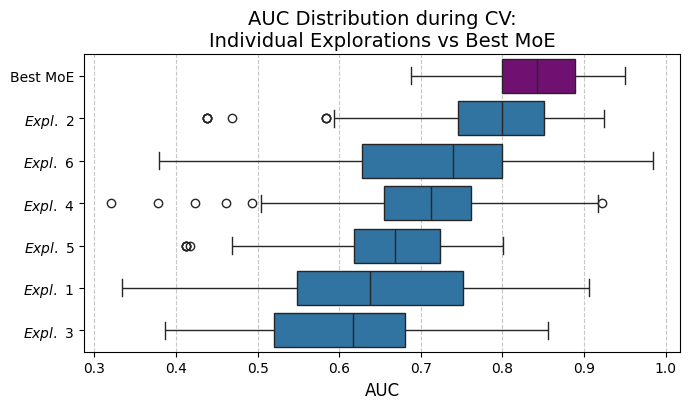

In [16]:
# Drop the metric columns from chosen_models (keep only identifiers and parameters)
chosen_keys = chosen_models.drop(columns=[
    'mean_test_roc_auc', 'sd_test_roc_auc',
    'mean_test_f1', 'sd_test_f1'
])

# Merge with cv_full_svm to retain only the per-fold results for the selected configurations
subset_cv_top_models = cv_full_svm.merge(
    chosen_keys,
    on=['exploration', 'dataset', 'kernel', 'C', 'gamma', 'k'],
    how='inner'
)

# Individual-exploration AUC distributions
exploration_df = subset_cv_top_models[['exploration', 'fold', 'test_roc_auc']].copy()
exploration_df['Model'] = exploration_df['exploration']
exploration_df = exploration_df.rename(columns={'test_roc_auc': 'auc'})
exploration_df = exploration_df[['Model', 'fold', 'auc']]

# Best-MoE AUC distribution (the exact variable set/threshold chosen above)
best_model_keys = best_model[['model', 'variables_used']]
moe_top_df = moe_variable_selection_performance.merge(best_model_keys, on=['model', 'variables_used']).copy()
moe_top_df['Model'] = 'Best MoE'
moe_top_df = moe_top_df[['Model', 'fold', 'auc']]

combined_df = pd.concat([exploration_df, moe_top_df], ignore_index=True)

sorted_labels = (
    combined_df.groupby('Model')['auc']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

palette = {label: '#1f77b4' for label in combined_df['Model'].unique() if label.startswith("Exploration")}
palette['Best MoE'] = 'purple'

plt.figure(figsize=(7, 6 * 0.7))
ax = sns.boxplot(data=combined_df, x='auc', y='Model', order=sorted_labels, palette=palette)

new_labels = []
for lab in ax.get_yticklabels():
    text = lab.get_text()
    if text.startswith("Exploration_"):
        num = text.split("_")[1]
        new_labels.append(rf"$\mathit{{Expl.\ {num}}}$")
    else:
        new_labels.append(text)
ax.set_yticklabels(new_labels)

ax.set_xlabel("AUC", fontsize=12)
ax.set_ylabel("", fontsize=12)
ax.set_title("AUC Distribution during CV:\nIndividual Explorations vs Best MoE", fontsize=14)
ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("../plots/paper_figures/boxplots_individual_vs_moe.png", dpi=300)
plt.show()
